In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from pathlib import Path
project_root = Path.cwd().resolve().parents[0]

import pandas as pd
import matplotlib.pyplot as plt

from src.data.kaggle_loader import KaggleCSVLoader
from src.data.fred_downloader import FredYCDownloader

In [2]:
# loading yield curve dataset
loader_yc = FredYCDownloader()
df_yc = loader_yc.download() 
df_yc = df_yc.set_index('Date')
display(df_yc)
print(df_yc.info())

Treasury yield curve dataset already downloaded..


,1M,3M,6M,1Y,2Y,5Y,10Y,30Y
Date,,,,,,,,
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.57,5.07,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.62,5.11,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.69,5.17,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.72,5.20,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.71,5.19,5.59
...,...,...,...,...,...,...,...,...
2026-03-20,3.73,3.74,3.79,3.80,3.88,4.01,4.39,4.96
2026-03-23,3.73,3.74,3.77,3.76,3.83,3.95,4.34,4.91
2026-03-24,3.74,3.74,3.78,3.81,3.90,4.03,4.39,4.94


<class 'pandas.DataFrame'>
Index: 6433 entries, 2001-07-31 to 2026-03-26
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1M      6164 non-null   float64
 1   3M      6164 non-null   float64
 2   6M      6164 non-null   float64
 3   1Y      6164 non-null   float64
 4   2Y      6164 non-null   float64
 5   5Y      6164 non-null   float64
 6   10Y     6164 non-null   float64
 7   30Y     6164 non-null   float64
dtypes: float64(8)
memory usage: 515.1 KB
None


In [3]:
# descriptive stats
print(df_yc.describe().T)

      count      mean       std   min     25%   50%     75%   max
1M   6164.0  1.682443  1.835840  0.00  0.0800  0.99  2.7925  6.02
3M   6164.0  1.741126  1.843445  0.00  0.1000  1.08  3.0700  5.63
6M   6164.0  1.831298  1.828012  0.02  0.1500  1.20  3.2900  5.61
1Y   6164.0  1.898931  1.741119  0.04  0.2600  1.39  3.3700  5.49
2Y   6164.0  2.060616  1.583773  0.09  0.6100  1.67  3.5300  5.29
5Y   6164.0  2.597726  1.319469  0.19  1.5200  2.52  3.8000  5.23
10Y  6164.0  3.176321  1.170563  0.52  2.1975  3.23  4.2000  5.44
30Y  6164.0  3.795206  1.095576  0.99  2.9500  3.91  4.7100  5.92


In [4]:
# missing values if any
print("Missing values per each column\n")
print(df_yc.isna().sum())

Missing values per each column

1M     269
3M     269
6M     269
1Y     269
2Y     269
5Y     269
10Y    269
30Y    269
dtype: int64


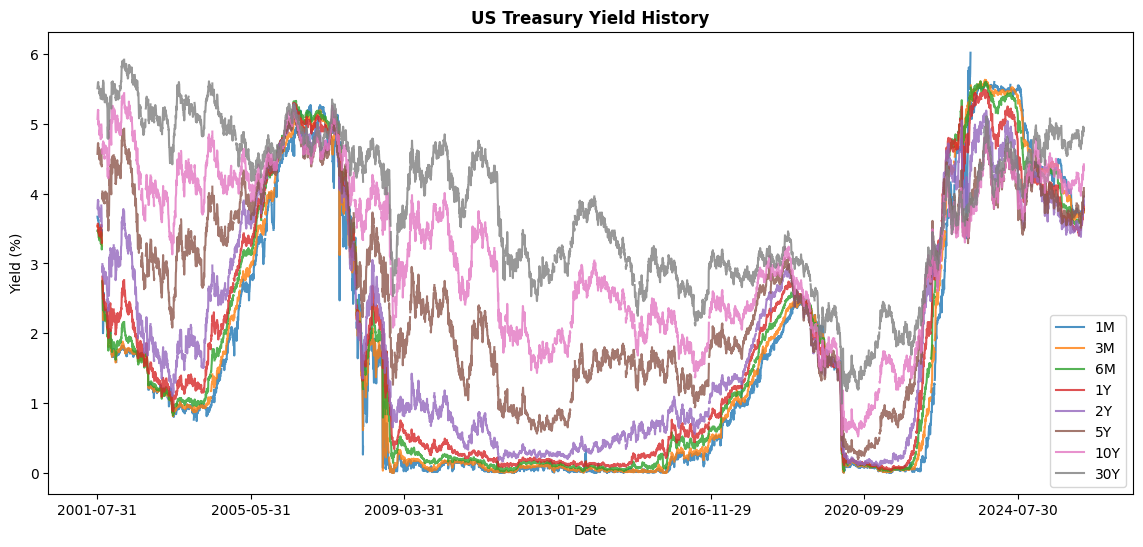

In [5]:
# plotting yield curve 
df_yc.plot(
    figsize = (14, 6),
    alpha = 0.8
)

plt.ylabel('Yield (%)')
plt.title('US Treasury Yield History', fontweight = 'bold')
plt.show()

In [ ]:
# data preprocessing 
df_yc = df_yc / 100
df_yc = df_yc.ffill()

# save locally
df_yc.to_csv("../data/processed/yield_curve_clean.csv")

,1M,3M,6M,1Y,2Y,5Y,10Y,30Y
Date,,,,,,,,
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.57,5.07,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.62,5.11,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.69,5.17,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.72,5.20,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.71,5.19,5.59
...,...,...,...,...,...,...,...,...
2026-03-20,3.73,3.74,3.79,3.80,3.88,4.01,4.39,4.96
2026-03-23,3.73,3.74,3.77,3.76,3.83,3.95,4.34,4.91
2026-03-24,3.74,3.74,3.78,3.81,3.90,4.03,4.39,4.94
